# ResNeXT vs ResNet-50

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class ResNeXtBottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, cardinality=32, base_width=4):
        super().__init__()

        width = int(out_channels * (base_width / 64.0)) * cardinality

        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width)

        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride,
                                padding=1, groups=cardinality, bias=False)
        self.bn2 = nn.BatchNorm2d(width)

        self.conv3 = nn.Conv2d(width, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

In [5]:
block_test = ResNeXtBottleneck(256, 64, stride=1, cardinality=32, base_width=4).to(device)
test_input = torch.randn(2, 256, 56, 56).to(device)
test_output = block_test(test_input)
print(f"{test_input.shape} -> {test_output.shape}")

computed_width = int(64 * (4 / 64.0)) * 32
print(f"Group conv width: {computed_width}")

torch.Size([2, 256, 56, 56]) -> torch.Size([2, 256, 56, 56])
Group conv width: 128


In [6]:
class ResNeXt50(nn.Module):
    layers_per_stage = [3, 4, 6, 3]
    stage_channels = [64, 128, 256, 512]
    CARDINALITY = 32
    BASE_WIDTH = 4

    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.stage1 = self._make_stage(64, self.layers_per_stage[0], stride=1)
        self.stage2 = self._make_stage(128, self.layers_per_stage[1], stride=2)
        self.stage3 = self._make_stage(256, self.layers_per_stage[2], stride=2)
        self.stage4 = self._make_stage(512, self.layers_per_stage[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * ResNeXtBottleneck.expansion, num_classes)

        self._initialize_weights()

    def _make_stage(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(ResNeXtBottleneck(
                self.in_channels, out_channels, stride=s,
                cardinality=self.CARDINALITY, base_width=self.BASE_WIDTH,
            ))
            self.in_channels = out_channels * ResNeXtBottleneck.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.fc(x)

model = ResNeXt50(num_classes=10).to(device)
print(model)

ResNeXt50(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (stage1): Sequential(
    (0): ResNeXtBottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [32, 10]

Output shape: torch.Size([64, 10])


In [8]:
def count_conv_params(in_ch, out_ch, kernel_size, groups=1):
    return kernel_size * kernel_size * (in_ch // groups) * out_ch

def count_bn_params(num_features):
    return 2 * num_features

in_ch, out_ch = 256, 64
width = int(out_ch * (4 / 64.0)) * 32  # = 128

conv1 = count_conv_params(in_ch, width, 1)
bn1 = count_bn_params(width)
conv2_grouped = count_conv_params(width, width, 3, groups=32)
bn2 = count_bn_params(width)
conv3 = count_conv_params(width, out_ch * 4, 1)
bn3 = count_bn_params(out_ch * 4)

block_manual = conv1 + bn1 + conv2_grouped + bn2 + conv3 + bn3
block_torch = sum(p.numel() for p in model.stage1[1].parameters())

print(f"conv2 grouped (groups=32): {conv2_grouped:,}")
conv2_plain = count_conv_params(width, width, 3, groups=1)
print(f"conv2 if it were a plain conv (groups=1): {conv2_plain:,}")
print(f"Ratio: {conv2_plain / conv2_grouped:.0f}x fewer params with grouping")

print(f"\nResNeXtBottleneck manual total: {block_manual:,}")
print(f"ResNeXtBottleneck torch total:  {block_torch:,}")
assert block_manual == block_torch, "Mismatch in ResNeXtBottleneck parameter count"

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal ResNeXt-50 parameters: {total_params:,}")

conv2 grouped (groups=32): 4,608
conv2 if it were a plain conv (groups=1): 147,456
Ratio: 32x fewer params with grouping

ResNeXtBottleneck manual total: 71,168
ResNeXtBottleneck torch total:  71,168

Total ResNeXt-50 parameters: 23,000,394


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.0482 train_acc=0.2697 | val_loss=1.9744 val_acc=0.3141 | time=158.4s
Epoch 2/10 | train_loss=1.7744 train_acc=0.3901 | val_loss=1.8372 val_acc=0.3817 | time=158.8s
Epoch 3/10 | train_loss=1.6195 train_acc=0.4559 | val_loss=1.8573 val_acc=0.4104 | time=161.2s
Epoch 4/10 | train_loss=1.4924 train_acc=0.4972 | val_loss=1.4594 val_acc=0.5220 | time=160.6s
Epoch 5/10 | train_loss=1.4007 train_acc=0.5368 | val_loss=1.3864 val_acc=0.5501 | time=160.2s
Epoch 6/10 | train_loss=1.3325 train_acc=0.5656 | val_loss=1.4227 val_acc=0.5238 | time=160.2s
Epoch 7/10 | train_loss=1.2811 train_acc=0.5761 | val_loss=1.1231 val_acc=0.6260 | time=160.3s
Epoch 8/10 | train_loss=1.2314 train_acc=0.5955 | val_loss=1.1229 val_acc=0.6329 | time=160.6s
Epoch 9/10 | train_loss=1.1718 train_acc=0.6140 | val_loss=1.0367 val_acc=0.6622 | time=160.8s
Epoch 10/10 | train_loss=1.1318 train_acc=0.6270 | val_loss=1.0584 val_acc=0.6530 | time=160.9s


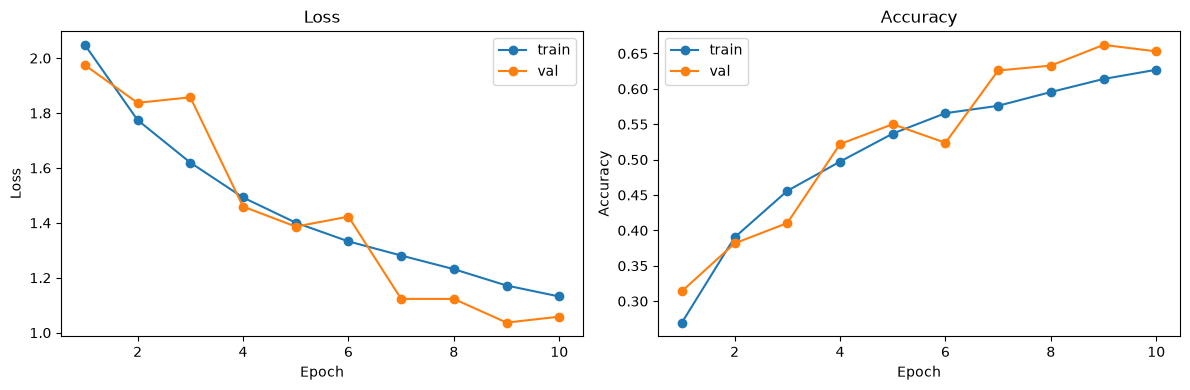

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

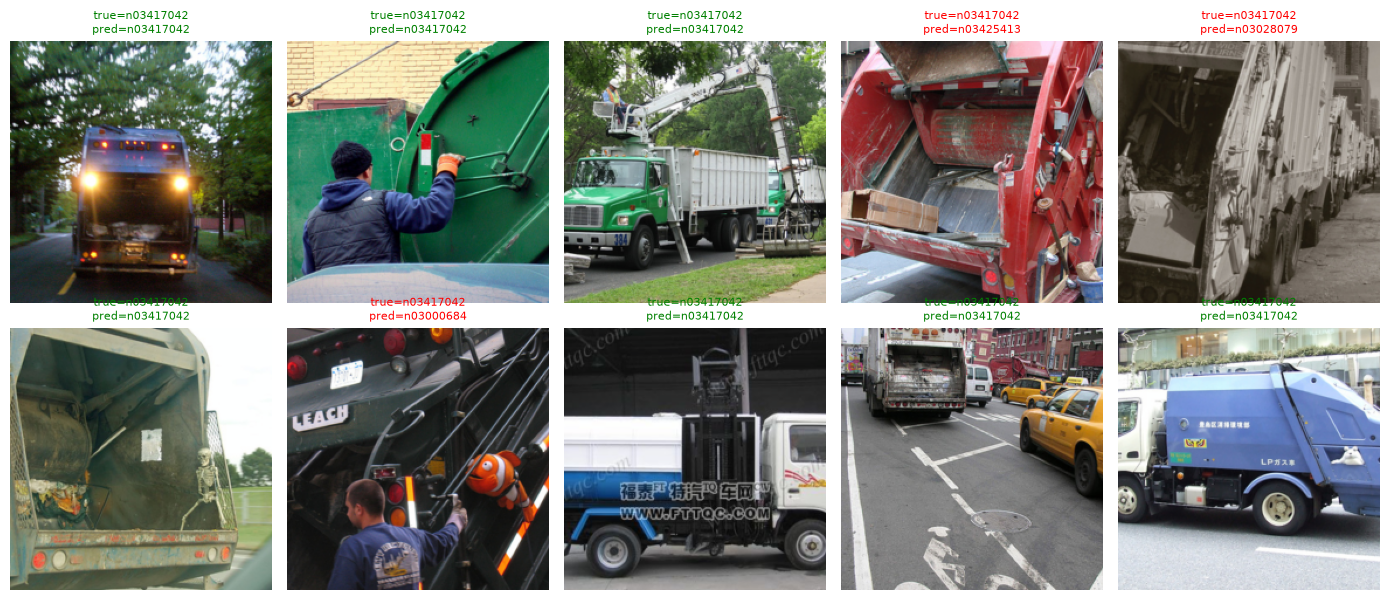

In [13]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: ~23M - close to ResNet-50's ~25M despite the architectural change, confirming
the design goal of the original paper (cardinality traded for width, not
an increase in overall budget).

**Grouped convolution parameter savings.** The middle 3x3 convolution inside
each block uses groups=32 instead of a plain convolution, cutting its
parameter count by roughly 32x - this saving is
what funds the wider intermediate representation (width=128 instead of 64)
at a comparable total parameter budget to plain ResNet-50.